## Setup & Download

In [1]:
# 1. Install & configure Kaggle
!pip install kaggle -q
from google.colab import files
files.upload()  # upload your kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# 2. Download competition data
!kaggle competitions download -c nlp-getting-started
!unzip nlp-getting-started.zip -d /content/data/

Saving kaggle.json to kaggle (1).json
nlp-getting-started.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  nlp-getting-started.zip
replace /content/data/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/data/sample_submission.csv  
replace /content/data/test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/data/test.csv  
replace /content/data/train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/data/train.csv  


## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

## Load Data

In [3]:
import pandas as pd

train = pd.read_csv('/content/data/train.csv')
test  = pd.read_csv('/content/data/test.csv')
sample_sub = pd.read_csv('/content/data/sample_submission.csv')

print(train.shape, test.shape)
train.head()

(7613, 5) (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [17]:
train.sample(10)

,keyword,location,text,target,text_len,clean_text
3074,electrocute,Naperville,Electrocute yourself,0,20,electrocute yourself
2693,detonation,unknown,Ignition Knock (Detonation) Sensor-KNOCK SENSO...,0,108,ignition knock detonation sensorknock sensor d...
2717,devastated,unknown,Zayn Malik &amp; Perrie Edwards End Engagement...,1,118,zayn malik amp perrie edwards end engagement s...
6381,suicide%20bomb,Homs- Syria,11 soldiers killed in ISIS suicide bomb in air...,1,125,soldiers killed in isis suicide bomb in air ba...
5280,outbreak,Chile,Families to sue over Legionnaires: More than 4...,1,136,families to sue over legionnaires more than fa...
1965,cyclone,"Hartford, connecticut",Bank manager asks Tom in an interview: 'What i...,0,106,bank manager asks tom in an interview what is ...
7254,weapons,St. Louis,In memory of the victims of Hiroshima and Naga...,1,111,in memory of the victims of hiroshima and naga...
7148,volcano,Indonesia,Zeal is a volcano the peak of which the grass ...,1,77,zeal is a volcano the peak of which the grass ...
2226,deluge,617-BTOWN-BEATDOWN,Photo: boyhaus: Heaven sent by JakeåÊ ÛÏAfter...,0,137,photo boyhaus heaven sent by jake after a very...
6352,structural%20failure,unknown,Slums are a manifestation state failure to pro...,1,138,slums are a manifestation state failure to pro...


## EDA

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [5]:
train.isnull().sum()

,0
id,0
keyword,61
location,2533
text,0
target,0


In [6]:
train['keyword']  = train['keyword'].fillna('none')
train['location'] = train['location'].fillna('unknown')
test['keyword']   = test['keyword'].fillna('none')
test['location']  = test['location'].fillna('unknown')

train = train.drop(columns=['id'])
test_ids = test['id'].copy()
test = test.drop(columns=['id'])

print("Missing values handled")
print(train.isnull().sum())

Missing values handled
keyword     0
location    0
text        0
target      0
dtype: int64


In [15]:
train['target'].value_counts(normalize=True)

,proportion
target,
0,0.57034
1,0.42966


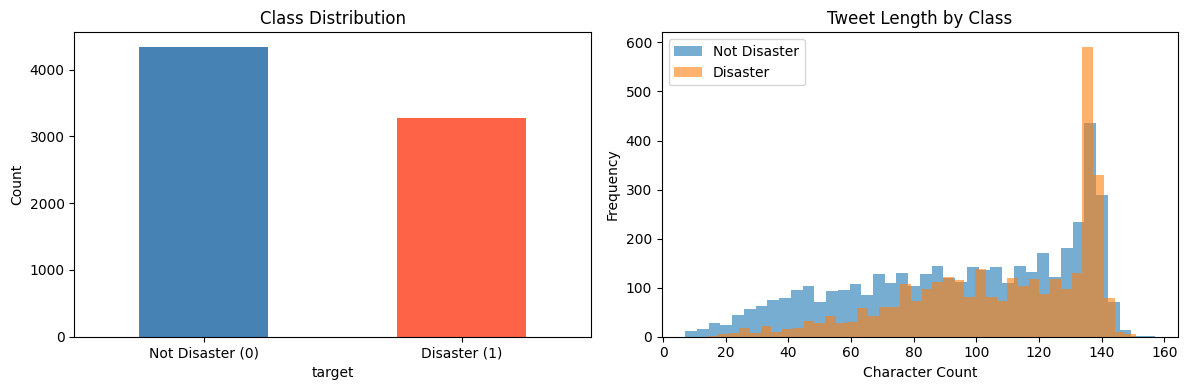

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
train['target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Not Disaster (0)', 'Disaster (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Tweet length distribution
train['text_len'] = train['text'].apply(len)
train.groupby('target')['text_len'].plot(kind='hist', alpha=0.6, bins=40, ax=axes[1], legend=True)
axes[1].set_title('Tweet Length by Class')
axes[1].set_xlabel('Character Count')
axes[1].legend(['Not Disaster', 'Disaster'])

plt.tight_layout()
plt.show()

In [9]:
print("Top 15 keywords in DISASTER tweets:")
print(train[train['target']==1]['keyword'].value_counts().head(15))

print("\nTop 15 keywords in NON-DISASTER tweets:")
print(train[train['target']==0]['keyword'].value_counts().head(15))

Top 15 keywords in DISASTER tweets:
keyword
none                   42
derailment             39
outbreak               39
wreckage               39
debris                 37
oil%20spill            37
typhoon                37
rescuers               32
suicide%20bomb         32
suicide%20bombing      32
evacuated              32
nuclear%20disaster     31
razed                  31
airplane%20accident    30
suicide%20bomber       30
Name: count, dtype: int64

Top 15 keywords in NON-DISASTER tweets:
keyword
body%20bags    40
armageddon     37
harm           37
ruin           36
wrecked        36
deluge         36
explode        35
twister        35
fear           35
siren          35
aftershock     34
panic          34
screaming      34
blizzard       33
blaze          33
Name: count, dtype: int64


## Text Preprocessing

In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['clean_text'] = train['text'].apply(clean_text)
test['clean_text']  = test['text'].apply(clean_text)


train[['text', 'clean_text']].head(3)

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...


## Model Training

In [11]:
X = train['clean_text']
y = train['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tf = tfidf.fit_transform(X_train)
X_val_tf   = tfidf.transform(X_val)

model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_tf, y_train)

y_pred = model.predict(X_val_tf)
print(f"Validation F1 Score: {f1_score(y_val, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Validation F1 Score: 0.7655

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.90      0.85       869
           1       0.84      0.71      0.77       654

    accuracy                           0.81      1523
   macro avg       0.82      0.80      0.81      1523
weighted avg       0.82      0.81      0.81      1523



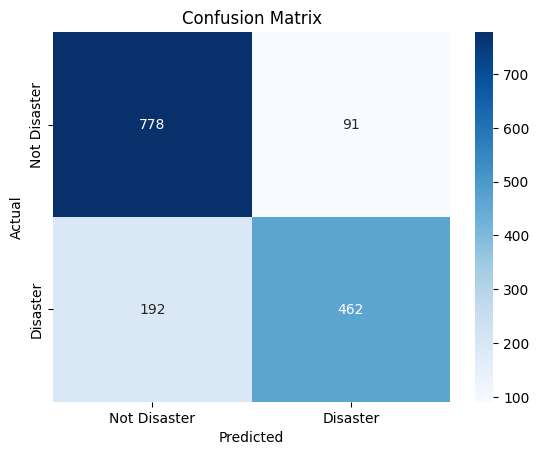

In [12]:
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Disaster','Disaster'],
            yticklabels=['Not Disaster','Disaster'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Submit Predictions

In [14]:
sub = pd.read_csv('/content/data/sample_submission.csv')

X_test_tf = tfidf.transform(test['clean_text'])
sub['target'] = model.predict(X_test_tf)

sub.to_csv('submission.csv', index=False)
print("submission.csv saved!")
print(sub['target'].value_counts())

!kaggle competitions submit -c nlp-getting-started -f submission.csv -m "TF-IDF + LogReg baseline"

submission.csv saved!
target
0    2169
1    1094
Name: count, dtype: int64
100% 22.2k/22.2k [00:00<00:00, 56.6kB/s]
Successfully submitted to Natural Language Processing with Disaster Tweets